# 0) Setup

We'll use matplotlib, seaborn, and pandas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import seaborn
import os

In [4]:
csv_path = 'sales_data/retail_sales.csv'

if os.path.exists(csv_path):
  data = pd.read_csv(csv_path)
  print("Data has been loaded successfully!")
else:
  print("File not found")

print(type(data))




Data has been loaded successfully!
<class 'pandas.core.frame.DataFrame'>


# 1) A quick introduction to the data

In [ ]:
# if we want to see how the data look like, we do this:
data.head(7)
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       120 non-null    object 
 1   Product    120 non-null    object 
 2   Category   120 non-null    object 
 3   Quantity   120 non-null    int64  
 4   UnitPrice  120 non-null    int64  
 5   Sales      120 non-null    float64
 6   Profit     120 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 6.7+ KB


,Quantity,UnitPrice,Sales,Profit
count,120.000000,120.000000,120.000000,120.000000
mean,32.666667,176.658333,5971.066667,1364.993500
std,16.715279,274.980534,11153.540414,2942.009853
min,5.000000,11.000000,138.000000,19.410000
25%,18.750000,39.750000,903.000000,180.242500
50%,32.000000,71.500000,1881.500000,415.775000
75%,48.000000,112.000000,4059.000000,933.430000
max,59.000000,1051.000000,56994.000000,19514.350000


# 2) Plot the trend of the data

Approach 1 -> Pyplot approach

Date
2024-01-01    115771.0
2024-02-01    179672.0
2024-03-01    146644.0
2024-04-01     69382.0
2024-05-01     85375.0
2024-06-01    119684.0
Name: Sales, dtype: float64


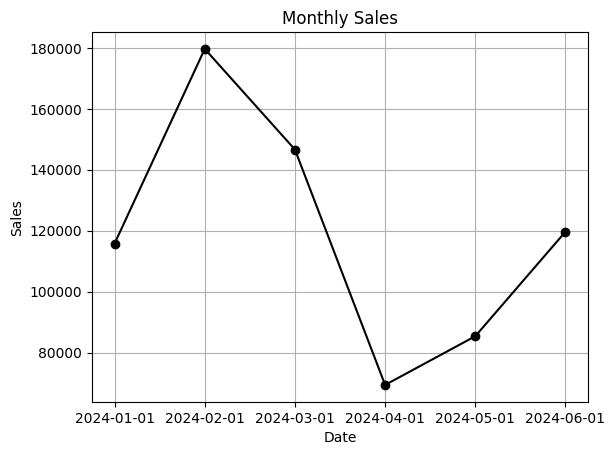

In [39]:
monthly_sale = data.groupby('Date')['Sales'].sum().sort_index()
monthly_profit = data.groupby('Date')['Profit'].sum().sort_index()
print(monthly_sale)
'''
# two separate plots
plt.figure()
plt.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'k')
plt.show()
plt.plot(monthly_profit.index, monthly_profit, marker = '*', color = 'r')
plt.show()

# one single plot with two curves
plt.figure()
plt.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'k')
plt.plot(monthly_profit.index, monthly_profit, marker = '*', color = 'r')
plt.show()
'''

plt.figure()
plt.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'k')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.grid(True)
plt.show()


Approach 2: Object Oriented API approach

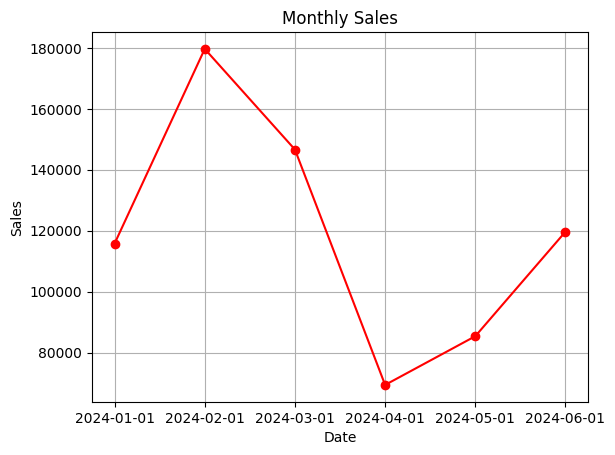

In [40]:
monthly_sale = data.groupby('Date')['Sales'].sum().sort_index()
monthly_profit = data.groupby('Date')['Profit'].sum().sort_index()


fig, ax = plt.subplots()
ax.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'r')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('Monthly Sales')
ax.grid(True)
plt.show()

# Bar plot

Category
Electronics    541941.0
Furniture       50938.0
Clothing        47216.0
Groceries       43589.0
Books           32844.0
Name: Sales, dtype: float64


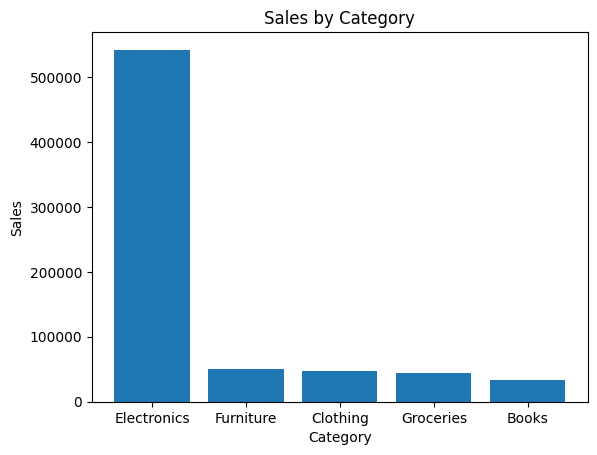

In [42]:
sales_by_cat = data.groupby('Category')['Sales'].sum().sort_values(ascending = False)
print(sales_by_cat)

fig, ax = plt.subplots()
ax.bar(sales_by_cat.index, sales_by_cat)
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
ax.set_title('Sales by Category')
plt.show()

# Scatterplot

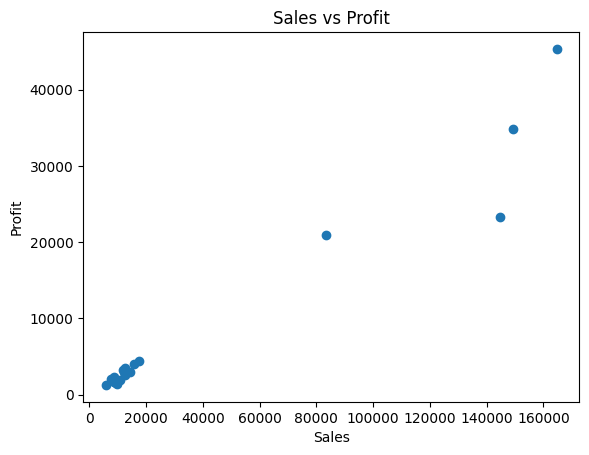

In [43]:
product = data.groupby(['Category', 'Product'])[['Sales', 'Profit']].sum().reset_index()

fig, ax = plt.subplots()
ax.scatter(product['Sales'], product['Profit'])
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
ax.set_title('Sales vs Profit')
plt.show()

# Histogram

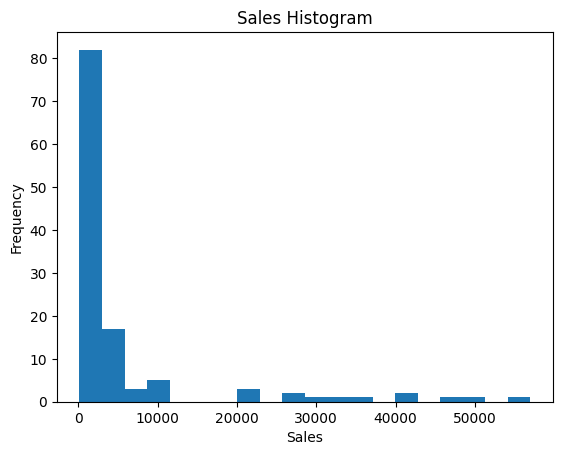

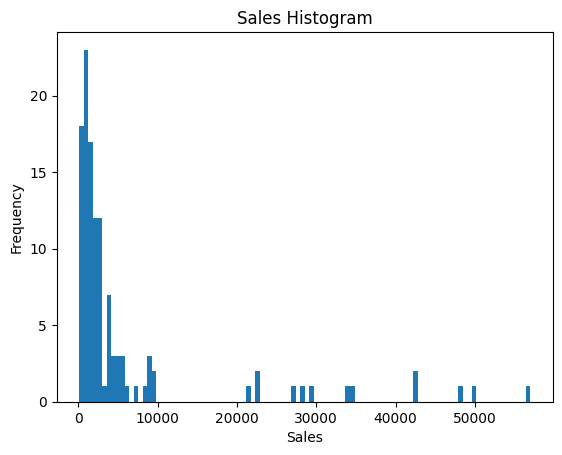

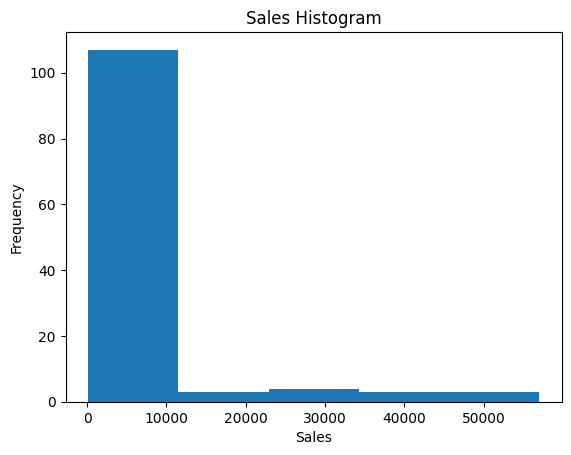

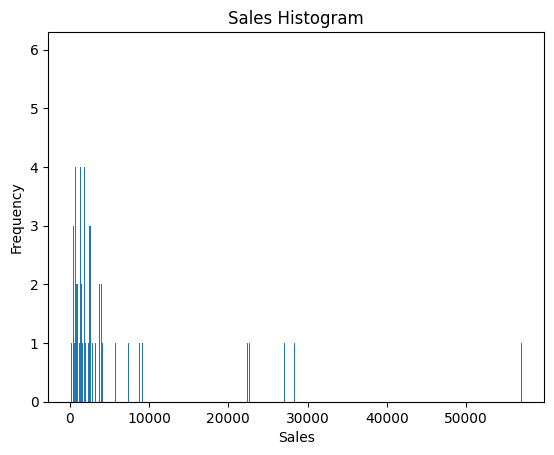

In [49]:
fig, ax = plt.subplots()
ax.hist(data['Sales'], bins = 20)
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
ax.set_title('Sales Histogram')
plt.show()

fig, ax = plt.subplots()
ax.hist(data['Sales'], bins = 100)
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
ax.set_title('Sales Histogram')
plt.show()

fig, ax = plt.subplots()
ax.hist(data['Sales'], bins = 5)
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
ax.set_title('Sales Histogram')
plt.show()

fig, ax = plt.subplots()
ax.hist(data['Sales'], bins = 1000)
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
ax.set_title('Sales Histogram')
plt.show()

# Boxplots

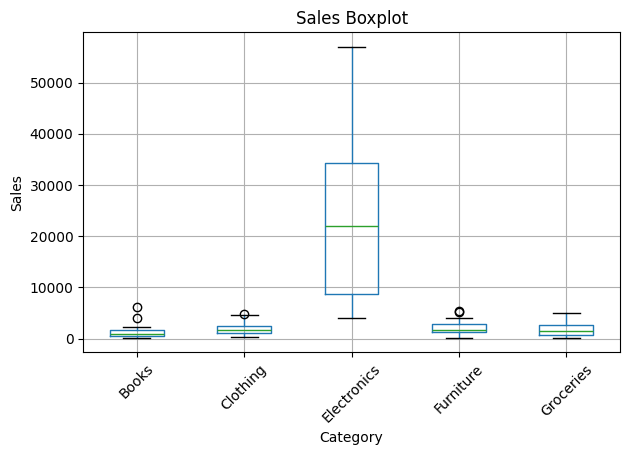

In [59]:
fig, ax = plt.subplots()
data.boxplot(column='Sales', by='Category', rot=45, ax=ax)
ax.set_ylabel('Sales')
ax.set_title('Sales Boxplot')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Save figures in matplotlib

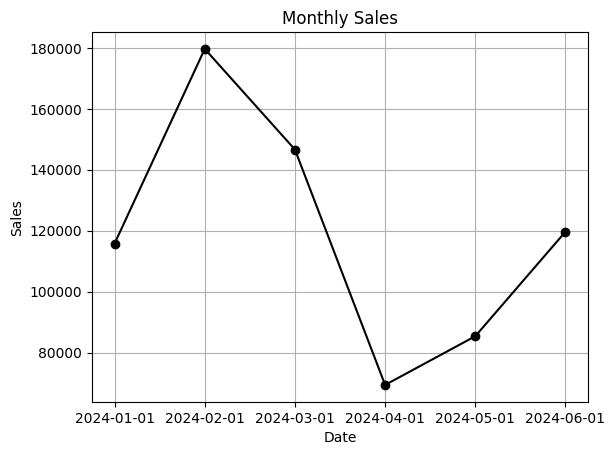

Figure is saved in the directry


In [61]:
fig, ax = plt.subplots()
ax.plot(monthly_sale.index, monthly_sale, marker = 'o', color = 'k')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.set_title('Monthly Sales')
ax.grid(True)
fig.savefig('monthly_sales.png')
plt.show()
print("Figure is saved in the directry")


# Summary

1) Importing pandas, numpy, matplotlib, seaborn
2) Bringing a csv file data into python
3) Start looking at the trend of sale (plt.plot)
4) having a bar plot to compare sales different in different categories
5) having a scatter plot to plot two different values w.r.t. each other (salevs vs. profit)
6) histogram to describe frequency of a value (sales)
7) boxplots useful for looking at Min, Max, Median, 25%, 75% of data in different categories.